# BLG454E Learning From Data Homework 1

All instructions about the homework are given in HW1_Fall2526.ipynb file. Do create any additional code or report files. Do not import additional libraries; only use the built-in functions and the libraries already imported in the notebook. Provide detailed comments and explanations for your results. If you have any questions, send an email to erzurumluoglu18@itu.edu.tr.

Name Surname: Madina Alzhanova

Student No: 150220939

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Part 1: Simple Linear Regression  (30 points)

### Background

Remember from the course material: In Linear Regression, we aim to find the line that fits the given data as well as possible. The line formula is:

### <center> $ \hat{y} = f(x) = \beta_0 + \beta_1 x $ <center> 

And using linear regression, the goal is to find the $\beta_0$ and $\beta_1$ such that the the Mean Squared Error (MSE) is minimized:
    
### <center> $ MSE \Rightarrow \mathcal{L} = \dfrac{1}{N} \sum_{i=1}^{N} (y_i - f(x_i ))^2 $ <center> 
    
As the MSE error gets smaller, the line starts to represent the data better and better.
    
Consider $\beta = (\beta_0 + \beta_1)$. In order to find the $\beta$ that minimizes the MSE loss, we use **Gradient Descent**. Iteratively $\beta$ is updated in the opposite direction of the gradient, while the size of the update is controlled with the learning rate $\eta$:
    
### <center> $ \beta \leftarrow \beta-\eta \frac{d \mathcal{L}}{d \beta} $ <center> 

### Your Task

In this part, you are going to code up Simple Linear Regression, and find the line that fits the data best. To do so, you'll need to complete the following:

- Code up the gradient descent, and print the loss value at every time step. You can use the number of steps as the stopping criteria (e.g. stopping gradient descent after 10 steps). 
- At the end of the algorithm, plot the found line with the data .
    
Given learning rate and number of iterations as default values in the code should work, but you are free to change them to make your algorithm faster if you'd like. You are not allowed to use any libraries other than the imported ones at the beginning. You can initialize the $\beta$ randomly.

In [ ]:
from sklearn.datasets import make_regression

def load_data():
    x, y = make_regression(n_samples=100, n_features=1, noise=10.0, bias=3.0, random_state=42)
    return x[:, 0], y

def gradient_descent(x, y, learning_rate = 0.1, max_its = 500):
#hardcoded for now
    beta0 = 1
    beta1 = 1

    mse_history = []

    # TO DO: calculate derivative (grad)
   
        # start gradient descent loop
    for k in range(0,max_its):
        y_hat = beta0 + beta1*x     #y_hat is array
        error = y - y_hat   #also array
        
        # TO DO: take gradient descent step
        grad_b0 = -2 * np.mean(error)
        grad_b1 = -2 * np.mean(x * error)   

        beta0 = beta0 - learning_rate * grad_b0
        beta1 = beta1 - learning_rate * grad_b1
        
        # TO DO: calculate and print the loss value
        mse = np.mean(error*error)
        mse_history.append(mse)

        print(f"Iteration {k}: loss = {mse:.4f}")
        
    print(f"\nFinal Loss: {mse:.4f}")
    return beta0, beta1, mse_history

Iteration 0: loss = 1620.4692
Iteration 1: loss = 1155.0241
Iteration 2: loss = 831.6908
Iteration 3: loss = 606.4868
Iteration 4: loss = 449.2511
Iteration 5: loss = 339.2278
Iteration 6: loss = 262.0859
Iteration 7: loss = 207.9003
Iteration 8: loss = 169.7770
Iteration 9: loss = 142.9150
Iteration 10: loss = 123.9628
Iteration 11: loss = 110.5755
Iteration 12: loss = 101.1090
Iteration 13: loss = 94.4088
Iteration 14: loss = 89.6625
Iteration 15: loss = 86.2979
Iteration 16: loss = 83.9111
Iteration 17: loss = 82.2170
Iteration 18: loss = 81.0140
Iteration 19: loss = 80.1593
Iteration 20: loss = 79.5518
Iteration 21: loss = 79.1199
Iteration 22: loss = 78.8127
Iteration 23: loss = 78.5942
Iteration 24: loss = 78.4387
Iteration 25: loss = 78.3280
Iteration 26: loss = 78.2492
Iteration 27: loss = 78.1931
Iteration 28: loss = 78.1532
Iteration 29: loss = 78.1247
Iteration 30: loss = 78.1044
Iteration 31: loss = 78.0900
Iteration 32: loss = 78.0797
Iteration 33: loss = 78.0724
Iteration

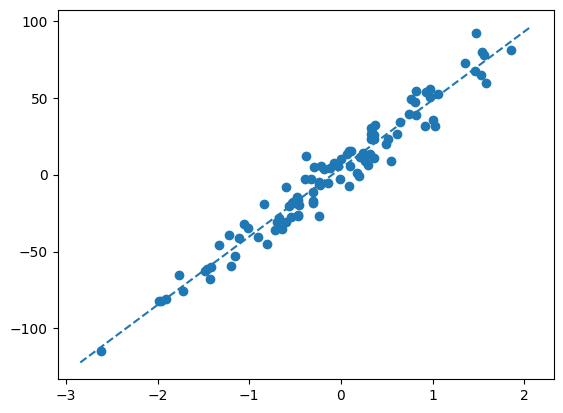

In [15]:
x, y = load_data()
beta0, beta1, _ = gradient_descent(x, y)
plt.scatter(x, y)
axes = plt.gca()
x_vals = np.array(axes.get_xlim())
y_vals = beta0 + beta1 * x_vals
plt.plot(x_vals, y_vals, '--')
plt.show()


# Part 2: Multi Linear Regression on California House Pricing Dataset using 5-fold Cross Validation (20 points)

In this part, you are going to train a Multi Linear Regression Model on a real dataset! The dataset we are going to use is **California House Pricing Dataset**. The target is to predict the median house value in California, given the 8 features ( You can examine the name of the features when you run the load_data function given below ). In this part, you will also use Cross-Validation with 5 folds, in addition to everything you implemented in Part 1. You will also alter your code so that it works with multiple attribute. In this case, you will have 8 features and you can code up assuming you will always have 8 features. At the end, you will report your results. 

In summary, you will need to do the following:

- Code up gradient descent with Cross Validation for Multi Linear Regression
- Find the best working learning rate and number of iterations setup.
- Report the MSE loss periodically during training in folds (For example, if you are training for 1000 steps, you can print MSE loss for each 100 steps. If you are training for 100000 steps ( which you can, if you'd like ), you can print MSE loss for each 10000 steps. In total, if you print the loss 10 times periodically for each fold, it's fine ).
- Save the final MSE results on the testing set on each fold in an array. Print the average testing MSE losses at the end of the algorithm. Additionally, print the variance of the testing MSE losses. 

In this part, we are giving you only the load_data function, so you are flying solo for Linear Regression Part! It is up to you to find the working learning rate and number of iterations setup. In addition to the libraries imported for Part 1, you are allowed to use sklearn for fetching dataset (which is already done for you), and the KFold class for the cross-validation. Other than that, you are not allowed to use sklearn or any other additional libraries.



In [39]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import KFold
def load_data():
    data= fetch_california_housing()
    print("Features of Boston Housing Prices dataset: ", data.get("feature_names"))
    print("Shape of the X: ", data.data.shape)
    print("Shape of the Y: ", data.target.shape)
    return data.data, data.target


def calculate_mse(Y_hat, Y):
    m = len(Y)
    error = Y_hat - Y
    return (1/m)*np.sum(error*error)

def z_score_normalize(data_to_scale, means=None, stds=None):
    if means is None or stds is None:
        means = np.mean(data_to_scale, axis=0)
        stds = np.std(data_to_scale, axis=0)
        stds_safe = np.where(stds == 0, 1, stds)
    else:
        stds_safe = stds
        
    scaled_data = (data_to_scale - means) / stds_safe
    
    return scaled_data, means, stds_safe

def train_gradient_descent(X, Y, learning_rate, max_its, print_period):
    m, n_features = X.shape
    theta = np.zeros(n_features)
    mse_history = []

    for k in range(1, max_its + 1):
        y_hat = X @ theta
        error = y_hat - Y

        grad = (1/m)*(X.T @ error)
        theta = theta - learning_rate*grad

        mse = calculate_mse(y_hat, Y)
        mse_history.append(mse)

        if k % print_period == 0 or k == 1:
            print(f"  Iteration {k:5d}/{max_its}: Training MSE (Normalized Y) = {mse:.6f}") 

    print(f"\nFinal Loss (MSE): {mse:.6f}")

    return theta

def multiple_gradient_descent_KFold(X_raw, Y_raw, learning_rate=0.1, max_its=5000, n_splits=5):

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    test_mse_results = []
    print_period = max(1, max_its // 10) 

    for fold, (train_index, test_index) in enumerate(kf.split(X_raw)):
        print(f"\n## Fold {fold + 1}/{n_splits} - Training")
        
        # 0. Data Split
        X_train_raw, X_test_raw = X_raw[train_index], X_raw[test_index]
        Y_train_raw, Y_test_raw = Y_raw[train_index], Y_raw[test_index]
        
        # 1. Normalize
        X_train_norm, X_mean, X_std = z_score_normalize(X_train_raw)
        Y_train_norm, Y_mean, Y_std = z_score_normalize(Y_train_raw.reshape(-1, 1))
        Y_train_norm = Y_train_norm.flatten() 
        Y_std = Y_std[0] 

        # 2. Add Intercept Col
        X_train_processed = np.c_[np.ones((X_train_norm.shape[0], 1)), X_train_norm]
        
        # 3. Train Model
        final_theta = train_gradient_descent(
            X_train_processed, Y_train_norm, learning_rate, max_its, print_period
        )
#eval:
        # 4. Prepare Test Data using Train Set scaling factors
        X_test_norm, _, _ = z_score_normalize(X_test_raw, means=X_mean, stds=X_std)
        
        # 5. Add Intercept Column (to test data)
        X_test_processed = np.c_[np.ones((X_test_norm.shape[0], 1)), X_test_norm]
        
        # 6. Predict and Denormalize
        predictions_norm = X_test_processed @ final_theta
        predictions_raw = (predictions_norm * Y_std) + Y_mean
        
        # 7. Calculate Final MSE on RAW Test Data
        test_mse = calculate_mse(predictions_raw, Y_test_raw)
        
        print(f"\nFinal Test MSE (Original Scale): **{test_mse:.4f}**")
        test_mse_results.append(test_mse)
        print("-" * 60)

    test_mse_results = np.array(test_mse_results)
    average_mse = np.mean(test_mse_results)
    variance_mse = np.var(test_mse_results)
    
    print("\nFinal Results")
    print(f"Testing MSEs per Fold: {test_mse_results.round(4)}")
    print(f"Average Testing MSE:** **{average_mse:.4f}")
    print(f"Variance of Testing MSE:** **{variance_mse:.6f}")
    print("-" * 60)
    
    return average_mse, variance_mse
    

    

In [40]:
x, y = load_data()
multiple_gradient_descent_KFold(x, y)

Features of Boston Housing Prices dataset:  ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Shape of the X:  (20640, 8)
Shape of the Y:  (20640,)

## Fold 1/5 - Training
  Iteration     1/5000: Training MSE (Normalized Y) = 1.000000
  Iteration   500/5000: Training MSE (Normalized Y) = 0.387558
  Iteration  1000/5000: Training MSE (Normalized Y) = 0.387450
  Iteration  1500/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  2000/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  2500/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  3000/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  3500/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  4000/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  4500/5000: Training MSE (Normalized Y) = 0.387449
  Iteration  5000/5000: Training MSE (Normalized Y) = 0.387449

Final Loss (MSE): 0.387449

Final Test MSE (Original Scale): **0.5559**
-------------

(np.float64(0.5305724639232163), np.float64(0.0004739909337740378))

# Part 3: Gaussian Naive Bayes Classifier (30 points)

### Background
Gaussian Naive Bayes classifiers combine class-conditional likelihoods with Bayes’ rule. In Gaussian Naive Bayes (GNB), each feature is assumed conditionally independent given the class and follows a Gaussian distribution:

### <center> $ \displaystyle p(x~|~C_k) = \prod^{d}_{j=1} \mathcal{N} (x_j~ |~ \mu_{kj}, \sigma^2_{kj}) $ <center> 

Working in the log domain is numerically stable. The decision rule compares class scores

### <center> $ \displaystyle \log P(C_k) + \sum^{d}_{j=1} \biggr[ - \dfrac{1}{2} \log (2 \pi \sigma^2_{kj}) - \dfrac{(x_j - \mu_{kj})^2}{2\sigma^2_{kj}} \biggr] $ <center>

and predicts the class with the largest score:

### <center> $ \hat{y} = \arg\max_k [ \log P(C_k) + \log p(x~|~C_k) ] $ <center> 

Because the covariance is assumed to be diagonal (independence), GNB is fast and robust with limited data.

### Your Task
In this part, you will implement Gaussian Naive Bayes from scratch and evaluate it with a single train/test split.
- First, you will calculate the class statistics:
    - Class priors 
    - Class-conditional means 
    - Class-conditional variances
    - Add a small $\epsilon$ to each variance for numerical stability.
- Then, to predict, compute log-likelihoods + log-priors and choose the class.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

def load_data():
    data = load_iris()
    X, y = data.data, data.target
    print("Classes:", np.unique(y))
    print("X shape:", X.shape, "y shape:", y.shape)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    return X_train, X_test, y_train, y_test

def compute_class_stats(X_train: np.ndarray, y_train: np.ndarray, epsilon: float = 1e-9) -> dict:
    classes = np.unique(y_train)
    num_train_samples = len(X_train)
    stats = {}

    for k in classes:  
        X_k = X_train[y_train == k]     #current class
        num_k_samples = len(X_k)

        prior = np.log(num_k_samples / num_train_samples)

        mean_k = np.mean(X_k, axis=0)   
        var_k = np.var(X_k, axis=0) + epsilon

        stats[k] = {
            'prior': prior,
            'mean_k': mean_k,
            'var_k': var_k
        }
    return stats




def predict_gnb(X_test:np.ndarray, stats: dict) -> np.ndarray:
    num_samples = X_test.shape[0]
    classes = sorted(stats.keys())

    log_scores = np.zeros((num_samples, len(classes)))  #contains (log P(C_k) + log p(x|C_k))
    for idx, k in enumerate(classes):
        prior = stats[k]['prior']
        mean_k = stats[k]['mean_k']
        var_k = stats[k]['var_k']

        log_norm_term = -0.5 * np.log(2 * np.pi * var_k)
        log_exponent_term = -0.5 * ((X_test - mean_k) ** 2) / var_k
        log_likelihood = np.sum(log_norm_term + log_exponent_term, axis=1)

        log_scores[:, idx] = prior + log_likelihood

    y_pred_indices = np.argmax(log_scores, axis=1)
    y_pred = np.array([classes[i] for i in y_pred_indices])

    return y_pred

def print_accuracy(y_true: np.ndarray, y_pred: np.ndarray):
    correct_predictions = (y_true == y_pred)
    num_correct = np.sum(correct_predictions)
    accuracy = num_correct / len(y_true)
    print(f"\nClassification Accuracy: {accuracy:.4f}")

def calculate_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> tuple:
    labels = np.unique(np.concatenate((y_true, y_pred)))
    num_classes = len(labels)
    label_to_index = {label: i for i, label in enumerate(labels)}

    cm = np.zeros((num_classes, num_classes), dtype=int)    #zero init

    for true_label, pred_label in zip(y_true, y_pred):
        # row(i) is True label
        i = label_to_index[true_label]
        # Col (j) is Predicted label
        j = label_to_index[pred_label]
        cm[i, j] += 1
        
    return cm, labels

def plot_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray):
    """Plots the confusion matrix using ONLY Matplotlib."""
    
    cm, labels = calculate_confusion_matrix(y_true, y_pred)
    num_classes = len(labels)
    
    plt.figure(figsize=(8, 6))
    
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix for GNB')
    plt.colorbar()
    
    # Set axis ticks and labels
    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, labels, rotation=45)
    plt.yticks(tick_marks, labels)
    
    # Annotate the matrix with counts
    thresh = cm.max() / 2.
    for i in range(num_classes):
        for j in range(num_classes):
            plt.text(j, i, format(cm[i, j], 'd'),
                     ha="center", va="center",
                     color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()    



Classes: [0 1 2]
X shape: (150, 4) y shape: (150,)

Classification Accuracy: 0.9667


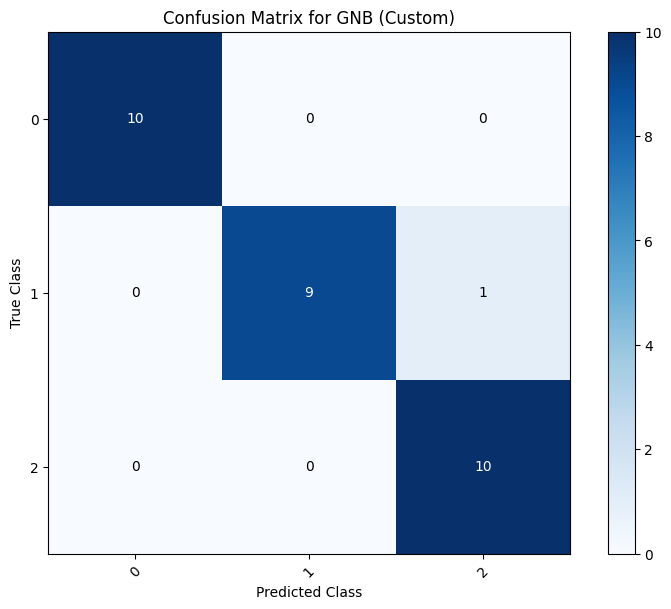

In [42]:
X_train, X_test, y_train, y_test = load_data()
stats = compute_class_stats(X_train, y_train)
y_pred = predict_gnb(X_test, stats)
print_accuracy(y_test, y_pred)
plot_confusion_matrix(y_test, y_pred)

# Part 4: Probability Questions (20 Points)

In this part, you are given 2 probability questions that you will solve by hand (You do not code anything). We ask you to insert an image of your handwritten solution on paper. If you drag & drop or paste an image into a Markdown cell, it’s stored as an attachment. This way, you do not have to keep the image in local, it will be directly embedded in the notebook file. Try to keep your answers as illustrative as possible.

### Question 1

Luna and Pasha are two cats with different wet-food schedules. On any given day, Luna gets wet food with probability 0.45, and Pasha gets wet food with probability 0.35. (Assume these events are independent.)

If both cats get wet food on the same day, they are extra excited, and the probability that they fight is 0.25. Otherwise, when at least one of them does not get wet food, the probability that they fight is 0.06.

For a randomly selected day:
- What is the probability that Luna gets wet food, Pasha does not, and the cats do not fight?
- What is the overall probability that the cats fight?

![Question 1](https://drive.google.com/file/d/1Gl80MsjrlB_KC2MM8m7ps0zLWj9kKg0t/view?usp=sharing)

### Question 2

Two identical-looking bowls of chips sit on the table. One bowl is a Fiery Mix, where each chip is very spicy with probability 0.65. The other is a Mild Mix where each chip is very spicy with probability 0.25. You don’t know which bowl is which. You picked one bowl at random and then ate 14 chips.

- What is the probability of getting exactly 6 very spicy chips?
- What is the probability of getting at least 11 very spicy chips?


image.png

![Question 2a](./Q2_a.jpg)

![Question 2b](./Q2_b.jpg)